# Apply `policlim` to Colombian 2026 manifestos

This notebook downloads the 2026 manifesto PDFs from the Green Backlash Colombia repository, extracts their text, classifies sentence-level text with [`marysanford/policlim`](https://huggingface.co/marysanford/policlim), and saves sentence-level predictions and manifesto-level climate-salience shares.

The model was developed for political manifesto text. Its authors recommend manually validating samples of predictions, especially when applying it to a new source or language.

In [1]:
%pip install -q pandas pypdf requests torch transformers

Note: you may need to restart the kernel to use updated packages.


In [8]:
from pathlib import Path
import json
import re
import unicodedata

import pandas as pd
import requests
from pypdf import PdfReader
from transformers import pipeline

# This notebook is intended to run from code/analysis.
PROJECT_ROOT = Path.cwd().resolve().parent.parent
PDF_DIR = PROJECT_ROOT / "data" / "manifestos" / "raw" / "2026"
OUTPUT_DIR = PROJECT_ROOT / "output" / "manifestos" / "policlim_2026"
PDF_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REPO_API_URL = "https://api.github.com/repos/bezisch/Green_Backlash_Colombia/contents/data/manifestos/raw/2026"
REPO_RAW_BASE_URL = "https://raw.githubusercontent.com/bezisch/Green_Backlash_Colombia/main/data/manifestos/raw/2026"
MODEL_ID = "marysanford/policlim"

print(f"Project root: {PROJECT_ROOT}")
print(f"PDF directory: {PDF_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Project root: /home/charlott
PDF directory: /home/charlott/data/manifestos/raw/2026
Output directory: /home/charlott/output/manifestos/policlim_2026


In [9]:
# Discover the repository's PDFs rather than relying on hard-coded filenames.
response = requests.get(REPO_API_URL, timeout=60)
response.raise_for_status()
remote_files = [item for item in response.json() if item.get("type") == "file" and item.get("name", "").lower().endswith(".pdf")]
if not remote_files:
    raise FileNotFoundError(f"No PDF files found at {REPO_API_URL}")

download_manifest = []
for item in remote_files:
    filename = item["name"]
    destination = PDF_DIR / filename
    if not destination.exists() or destination.stat().st_size == 0:
        pdf_response = requests.get(item["download_url"], timeout=120)
        pdf_response.raise_for_status()
        destination.write_bytes(pdf_response.content)
        action = "downloaded"
    else:
        action = "already present"
    download_manifest.append({
        "filename": filename,
        "local_path": str(destination),
        "source_url": item["html_url"],
        "raw_url": item["download_url"],
        "action": action,
    })

pd.DataFrame(download_manifest)

,filename,local_path,source_url,raw_url,action
0,Claudia-lopez-Programa-Gobierno-nueva-historia...,/home/charlott/data/manifestos/raw/2026/Claudi...,https://github.com/bezisch/Green_Backlash_Colo...,https://raw.githubusercontent.com/bezisch/Gree...,already present
1,PROPUESTAS-DEL-TIGRE.pdf,/home/charlott/data/manifestos/raw/2026/PROPUE...,https://github.com/bezisch/Green_Backlash_Colo...,https://raw.githubusercontent.com/bezisch/Gree...,already present
2,Plan Integrado de Gobierno Final_compressed.pdf,/home/charlott/data/manifestos/raw/2026/Plan I...,https://github.com/bezisch/Green_Backlash_Colo...,https://raw.githubusercontent.com/bezisch/Gree...,already present
3,Programa-Dignidad-Compromiso.pdf,/home/charlott/data/manifestos/raw/2026/Progra...,https://github.com/bezisch/Green_Backlash_Colo...,https://raw.githubusercontent.com/bezisch/Gree...,already present
4,programa-gobierno-2026-2030.pdf,/home/charlott/data/manifestos/raw/2026/progra...,https://github.com/bezisch/Green_Backlash_Colo...,https://raw.githubusercontent.com/bezisch/Gree...,already present


In [10]:
def clean_text(text):
    text = unicodedata.normalize("NFC", text or "")
    text = text.replace("\x00", " ")
    return re.sub(r"\s+", " ", text).strip()

def extract_pdf_text(pdf_path):
    reader = PdfReader(str(pdf_path))
    page_text = [clean_text(page.extract_text()) for page in reader.pages]
    return clean_text(" ".join(page_text)), len(reader.pages), sum(bool(text) for text in page_text)
 
def split_into_sentences(text):
    # A lightweight splitter keeps the notebook self-contained and works for Spanish punctuation.
    candidates = re.split(r"(?<=[.!?])\s+(?=[A-ZÁÉÍÓÚÜÑ¿¡0-9])|[\r\n]+", text)
    return [sentence.strip() for sentence in candidates if len(sentence.split()) >= 3]

def split_long_sentence(sentence, max_words=350):
    words = sentence.split()
    return [" ".join(words[start:start + max_words]) for start in range(0, len(words), max_words)]

In [11]:
sentence_rows = []
source_urls = {item["filename"]: item["source_url"] for item in download_manifest}

for pdf_path in sorted(PDF_DIR.glob("*.pdf")):
    text, page_count, pages_with_text = extract_pdf_text(pdf_path)
    sentences = split_into_sentences(text)
    expanded_sentences = []
    for sentence in sentences:
        expanded_sentences.extend(split_long_sentence(sentence))

    for sentence_number, sentence in enumerate(expanded_sentences, start=1):
        sentence_rows.append({
            "manifesto_file": pdf_path.name,
            "manifesto_source_url": source_urls.get(pdf_path.name, f"{REPO_RAW_BASE_URL}/{pdf_path.name}"),
            "sentence_number": sentence_number,
            "text": sentence,
        })

sentences_df = pd.DataFrame(sentence_rows)
if sentences_df.empty:
    raise ValueError(f"No sentences extracted from PDFs in {PDF_DIR}")

print(f"Extracted {len(sentences_df):,} sentences from {sentences_df['manifesto_file'].nunique()} manifestos")
sentences_df.head()

Extracted 4,806 sentences from 5 manifestos


,manifesto_file,manifesto_source_url,sentence_number,text
0,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,1,1 2 3 4 5 danías históricamente excluidas; la ...
1,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,2,Lo que le sirve a las mayorías se queda y se p...
2,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,3,"A esos logros, vamos a sumar la creación de tr..."
3,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,4,"Al mismo tiempo, vamos a corregir lo que hoy v..."
4,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,5,Pondremos la casa en orden enfrentando tres cr...


In [13]:
# Load the published model. The model's config supplies the authoritative label names.
classifier = pipeline(
    task="text-classification",
    model=MODEL_ID,
    tokenizer=MODEL_ID,
    truncation=True,
    max_length=512,
    top_k=None,
)

id2label = classifier.model.config.id2label
print("Model labels:", id2label)

def normalise_predictions(batch_predictions):
    # Transformers versions differ slightly in their pipeline return shape.
    if batch_predictions and isinstance(batch_predictions[0], dict):
        batch_predictions = [batch_predictions]
    return batch_predictions

all_predictions = []
texts = sentences_df["text"].tolist()
for start in range(0, len(texts), 16):
    batch = normalise_predictions(classifier(texts[start:start + 16], batch_size=16))
    all_predictions.extend(batch)

def prediction_fields(predictions):
    by_label = {item["label"]: float(item["score"]) for item in predictions}
    top_label = max(by_label, key=by_label.get)
    climate_label = next((label for label in by_label if "1" in label.lower() or "climate" in label.lower() or "yes" in label.lower()), top_label)
    return top_label, by_label.get(climate_label, by_label[top_label]), climate_label, json.dumps(by_label, ensure_ascii=False)

fields = [prediction_fields(prediction) for prediction in all_predictions]
sentences_df[["predicted_label", "climate_score", "climate_label", "label_scores"]] = pd.DataFrame(fields, index=sentences_df.index)
sentences_df["climate_relevant"] = sentences_df["predicted_label"] == sentences_df["climate_label"]
sentences_df.head()

Device set to use cuda:0


Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


,manifesto_file,manifesto_source_url,sentence_number,text,predicted_label,climate_score,climate_label,label_scores,climate_relevant
0,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,1,1 2 3 4 5 danías históricamente excluidas; la ...,LABEL_0,0.000895,LABEL_1,"{""LABEL_0"": 0.9991053938865662, ""LABEL_1"": 0.0...",False
1,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,2,Lo que le sirve a las mayorías se queda y se p...,LABEL_0,0.000896,LABEL_1,"{""LABEL_0"": 0.9991040825843811, ""LABEL_1"": 0.0...",False
2,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,3,"A esos logros, vamos a sumar la creación de tr...",LABEL_0,0.000950,LABEL_1,"{""LABEL_0"": 0.9990501999855042, ""LABEL_1"": 0.0...",False
3,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,4,"Al mismo tiempo, vamos a corregir lo que hoy v...",LABEL_0,0.000984,LABEL_1,"{""LABEL_0"": 0.9990158081054688, ""LABEL_1"": 0.0...",False
4,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,5,Pondremos la casa en orden enfrentando tres cr...,LABEL_0,0.000960,LABEL_1,"{""LABEL_0"": 0.9990398287773132, ""LABEL_1"": 0.0...",False


In [22]:
# Aggregate sentence predictions into the manifesto-level share used by policlim.
summary_df = (
    sentences_df.groupby(["manifesto_file", "manifesto_source_url"], as_index=False)
    .agg(
        sentence_count=("text", "size"),
        climate_relevant_sentences=("climate_relevant", "sum"),
        climate_salience_share=("climate_relevant", "mean"),
        mean_climate_score=("climate_score", "mean"),
    )
)
summary_df["model_id"] = MODEL_ID
summary_df["model_labels"] = json.dumps(id2label, ensure_ascii=False)

sentence_output = OUTPUT_DIR / "policlim_2026_sentence_predictions.csv"
summary_output = OUTPUT_DIR / "policlim_2026_manifesto_summary.csv"
metadata_output = OUTPUT_DIR / "policlim_2026_run_metadata.json"
sentences_df.to_csv(sentence_output, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_output, index=False, encoding="utf-8-sig")
metadata_output.write_text(json.dumps({
    "model_id": MODEL_ID,
    "model_labels": id2label,
    "source_api_url": REPO_API_URL,
    "pdfs": download_manifest,
}, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"Saved: {sentence_output}")
print(f"Saved: {summary_output}")
print(f"Saved: {metadata_output}")
display(summary_df.sort_values("climate_salience_share", ascending=False))

Saved: /home/charlott/output/manifestos/policlim_2026/policlim_2026_sentence_predictions.csv
Saved: /home/charlott/output/manifestos/policlim_2026/policlim_2026_manifesto_summary.csv
Saved: /home/charlott/output/manifestos/policlim_2026/policlim_2026_run_metadata.json


,manifesto_file,manifesto_source_url,sentence_count,climate_relevant_sentences,climate_salience_share,mean_climate_score,model_id,model_labels
2,Plan Integrado de Gobierno Final_compressed.pdf,https://github.com/bezisch/Green_Backlash_Colo...,264,29,0.109848,0.111647,marysanford/policlim,"{""0"": ""LABEL_0"", ""1"": ""LABEL_1""}"
1,PROPUESTAS-DEL-TIGRE.pdf,https://github.com/bezisch/Green_Backlash_Colo...,29,3,0.103448,0.104284,marysanford/policlim,"{""0"": ""LABEL_0"", ""1"": ""LABEL_1""}"
0,Claudia-lopez-Programa-Gobierno-nueva-historia...,https://github.com/bezisch/Green_Backlash_Colo...,330,26,0.078788,0.075265,marysanford/policlim,"{""0"": ""LABEL_0"", ""1"": ""LABEL_1""}"
4,programa-gobierno-2026-2030.pdf,https://github.com/bezisch/Green_Backlash_Colo...,4073,87,0.021360,0.022714,marysanford/policlim,"{""0"": ""LABEL_0"", ""1"": ""LABEL_1""}"
3,Programa-Dignidad-Compromiso.pdf,https://github.com/bezisch/Green_Backlash_Colo...,110,2,0.018182,0.019319,marysanford/policlim,"{""0"": ""LABEL_0"", ""1"": ""LABEL_1""}"


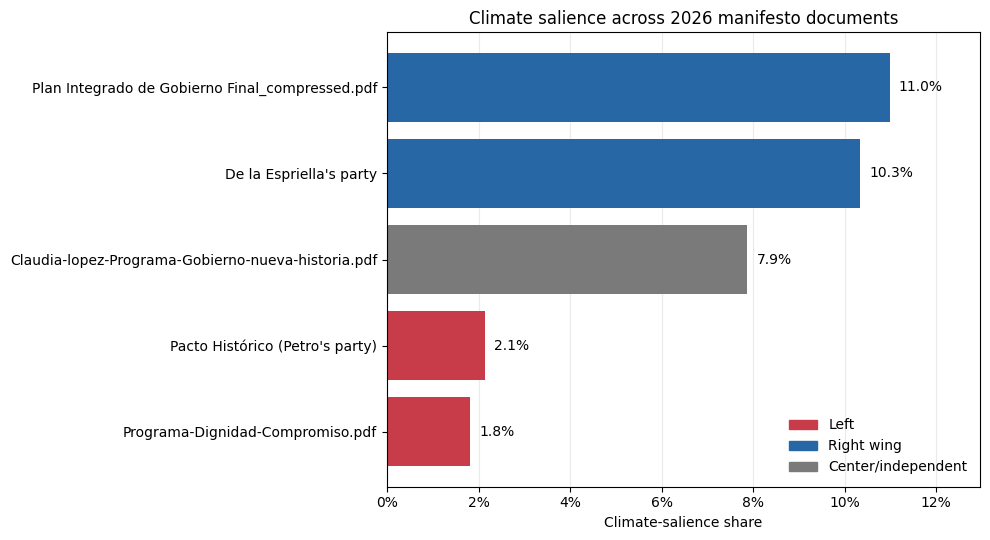

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plot_df = summary_df.sort_values("climate_salience_share", ascending=True).copy()
plot_df["label"] = plot_df["manifesto_file"]
plot_df.loc[
    plot_df["manifesto_file"] == "programa-gobierno-2026-2030.pdf",
    "label",
] = "Pacto Histórico (Petro's party)"
plot_df.loc[
    plot_df["manifesto_file"] == "PROPUESTAS-DEL-TIGRE.pdf",
    "label",
] = "De la Espriella's party"

left_party_files = {
    "programa-gobierno-2026-2030.pdf",
    "Programa-Dignidad-Compromiso.pdf",
}
right_wing_files = {
    "Plan Integrado de Gobierno Final_compressed.pdf",
    "PROPUESTAS-DEL-TIGRE.pdf",
}
plot_df["position"] = "Center/independent"
plot_df.loc[plot_df["manifesto_file"].isin(left_party_files), "position"] = "Left"
plot_df.loc[plot_df["manifesto_file"].isin(right_wing_files), "position"] = "Right wing"
position_colors = {
    "Left": "#c83c4a",
    "Right wing": "#2867a6",
    "Center/independent": "#7a7a7a",
}

fig, ax = plt.subplots(figsize=(10, 5.5))
bar_colors = plot_df["position"].map(position_colors)
bars = ax.barh(plot_df["label"], plot_df["climate_salience_share"], color=bar_colors)
ax.set_title("Climate salience across 2026 manifesto documents")
ax.set_xlabel("Climate-salience share")
ax.set_xlim(0, max(plot_df["climate_salience_share"]) * 1.18)
ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
for bar, value in zip(bars, plot_df["climate_salience_share"]):
    ax.text(value + 0.002, bar.get_y() + bar.get_height() / 2, f"{value:.1%}", va="center")
ax.legend(
    handles=[Patch(color=color, label=position) for position, color in position_colors.items()],
    loc="lower right",
    frameon=False,
)
fig.tight_layout()
plt.show()

## Manual validation

Review a random sample of high- and low-confidence predictions before using the aggregate scores substantively. The full sentence text, predicted label, probability by label, and source manifesto are in `policlim_2026_sentence_predictions.csv`.

In [32]:
validation_sample = sentences_df.sample(min(30, len(sentences_df)), random_state=42)[[
    "manifesto_file", "sentence_number", "text", "predicted_label", "climate_score", "label_scores"
]].sort_values(["manifesto_file", "sentence_number"])
display(validation_sample)

,manifesto_file,sentence_number,text,predicted_label,climate_score,label_scores
8,Claudia-lopez-Programa-Gobierno-nueva-historia...,9,Necesita un líder y un gobierno capaz de orden...,LABEL_0,0.000884,"{""LABEL_0"": 0.9991157650947571, ""LABEL_1"": 0.0..."
227,Claudia-lopez-Programa-Gobierno-nueva-historia...,228,Cada DPR estructurará directamente en los terr...,LABEL_0,0.000955,"{""LABEL_0"": 0.9990448355674744, ""LABEL_1"": 0.0..."
254,Claudia-lopez-Programa-Gobierno-nueva-historia...,255,"La Guajira, Cesar , Atlántico, Bolívar , Mag- ...",LABEL_1,0.999335,"{""LABEL_1"": 0.9993348717689514, ""LABEL_0"": 0.0..."
297,Claudia-lopez-Programa-Gobierno-nueva-historia...,298,Potenciaremos el AMAZONÍA 32 participación com...,LABEL_0,0.002004,"{""LABEL_0"": 0.9979962706565857, ""LABEL_1"": 0.0..."
794,programa-gobierno-2026-2030.pdf,62,385 LA REBELIÓN ANTIRRACISTAY EL DESARROLLO DE...,LABEL_0,0.001219,"{""LABEL_0"": 0.9987813830375671, ""LABEL_1"": 0.0..."
828,programa-gobierno-2026-2030.pdf,96,He trabajado incansable - mente por articular ...,LABEL_0,0.000916,"{""LABEL_0"": 0.9990842342376709, ""LABEL_1"": 0.0..."
1029,programa-gobierno-2026-2030.pdf,297,"Son ellas quienes, a través de su testimonio, ...",LABEL_0,0.000878,"{""LABEL_0"": 0.9991219639778137, ""LABEL_1"": 0.0..."
1448,programa-gobierno-2026-2030.pdf,716,Cuando las madres de los muchachos de los fals...,LABEL_0,0.000891,"{""LABEL_0"": 0.9991090893745422, ""LABEL_1"": 0.0..."
1553,programa-gobierno-2026-2030.pdf,821,"Por eso, no descansare- mos hasta ver que en c...",LABEL_0,0.000883,"{""LABEL_0"": 0.9991165995597839, ""LABEL_1"": 0.0..."
1586,programa-gobierno-2026-2030.pdf,854,Quiero afirmarlo con todas sus le - tras: avan...,LABEL_0,0.005605,"{""LABEL_0"": 0.9943954944610596, ""LABEL_1"": 0.0..."


## Abelardo de la Espriella: comparison and high-scoring text

In [23]:
# The repository currently names Abelardo de la Espriella's manifesto PROPUESTAS-DEL-TIGRE.pdf.
abelardo_matches = summary_df[summary_df["manifesto_file"].str.contains("abelardo|espriella|tigre", case=False, na=False)].copy()
if len(abelardo_matches) != 1:
    raise ValueError(f"Expected one Abelardo de la Espriella manifesto, found: {abelardo_matches['manifesto_file'].tolist()}")

abelardo_file = abelardo_matches.iloc[0]["manifesto_file"]
comparison = summary_df[["manifesto_file", "climate_salience_share", "sentence_count"]].copy()
comparison["rank"] = comparison["climate_salience_share"].rank(method="min", ascending=False).astype(int)
comparison["percentile"] = comparison["climate_salience_share"].rank(pct=True) * 100
abelardo_row = comparison[comparison["manifesto_file"] == abelardo_file].iloc[0]

print(f"Manifesto: {abelardo_file}")
print(f"Climate-salience share: {abelardo_row['climate_salience_share']:.1%}")
print(f"Rank: {int(abelardo_row['rank'])} of {len(comparison)} manifestos")
print(f"Percentile: {abelardo_row['percentile']:.1f}")
display(comparison.sort_values("climate_salience_share", ascending=False))

Manifesto: PROPUESTAS-DEL-TIGRE.pdf
Climate-salience share: 10.3%
Rank: 2 of 5 manifestos
Percentile: 80.0


,manifesto_file,climate_salience_share,sentence_count,rank,percentile
2,Plan Integrado de Gobierno Final_compressed.pdf,0.109848,264,1,100.0
1,PROPUESTAS-DEL-TIGRE.pdf,0.103448,29,2,80.0
0,Claudia-lopez-Programa-Gobierno-nueva-historia...,0.078788,330,3,60.0
4,programa-gobierno-2026-2030.pdf,0.021360,4073,4,40.0
3,Programa-Dignidad-Compromiso.pdf,0.018182,110,5,20.0


Interpretation

Abelardo de la Espriella's manifesto has a climate-salience share of **10.3%**, meaning that approximately one in ten extracted sentences was classified by `policlim` as climate-relevant. This places it **second among the five manifestos** in the current sample and at the **80th percentile** of climate salience. The result indicates relatively high climate salience compared with the other manifestos, but it is a descriptive model-based measure rather than evidence about the quality, ambition, or likely effects of the proposals. 

In [28]:
rank_1_file = comparison.sort_values(["rank", "climate_salience_share"], ascending=[True, False]).iloc[0]["manifesto_file"]
rank_1_row = comparison[comparison["manifesto_file"] == rank_1_file].iloc[0]
rank_1_sentences = (
    sentences_df[sentences_df["manifesto_file"] == rank_1_file]
    .sort_values(["climate_score", "sentence_number"], ascending=[False, True])
    .head(5)
)

print(f"Rank 1 manifesto: {rank_1_file}")
print(f"Climate-salience share: {rank_1_row['climate_salience_share']:.1%}")
for _, row in rank_1_sentences.iterrows():
    print(f"\n[{row['climate_score']:.1%}] Sentence {int(row['sentence_number'])}:\n{row['text']}")

Rank 1 manifesto: Plan Integrado de Gobierno Final_compressed.pdf
Climate-salience share: 11.0%

[99.9%] Sentence 44:
Afrontar la crisis energética significa recuperar la capacidad de producir, destrabar la inversión, garantizar tarifas justas y asegurar que el país tenga energía abundant e, confiable y suficiente para crecer, utilizando todos los recursos energéticos disponibles, incluyendo el gas y el carbón.

[99.9%] Sentence 59:
Impulsaremos energías alternativas y no convencionales como la eólica, solar, biomasa, geotérmica, hidrógeno y nuclear.

[99.9%] Sentence 58:
Impulsaremos nuevos proyectos de generación hidroeléctrica mediante embalses y a filo de agua (PCH).

[99.9%] Sentence 60:
Optimizaremos los nuevos recursos energéticos para permitir que Colombia participe en la revolución de la inteligencia artificial, con centros de datos y de procesamiento de bajo costo.

[99.9%] Sentence 229:
Los recursos generados por la explotación legal de minas, petróleo, energía y gas deben f

In [26]:
# Print fifteen Abelardo sentences with the highest model probability for the climate-relevant label.
abelardo_sentences = sentences_df[sentences_df["manifesto_file"] == abelardo_file].copy()
top_sentences = abelardo_sentences.sort_values(["climate_score", "sentence_number"], ascending=[False, True]).head(15)
for _, row in top_sentences.iterrows():
    print(f"\n[{row['climate_score']:.1%}] Sentence {int(row['sentence_number'])}:\n{row['text']}")


[99.9%] Sentence 18:
8 LA POLÍTICA MINERO ENERGÉTICA DE LA PATRIA MILAGRO * Argumento central: Colombia no puede seguir tratando el sector minero-energético con prejuicios ideológicos ni improvisación, porque de él dependen la seguridad energética, la competitividad, el empleo, la estabilidad ﬁscal y una parte decisiva de la inversión regional y social.

[99.9%] Sentence 19:
El problema no es la falta de recursos, sino la falta de decisiones serias para convertirlos en seguridad energética y ﬁscal. * Propuestas clave: ▪ Recuperar la exploración y la producción de petróleo y gas con seguridad jurídica y criterio técnico. ▪ Fortalecer la autosuﬁciencia energética. ▪ Tratar el gas como asunto estratégico acelerando campos descubiertos, proyectos costa afuera, transporte e infraestructura, y evaluando con rigor los yacimientos no convencionales. ▪ Transformar el sistema eléctrico de la Costa Caribe. ▪ Defender a Ecopetrol como activo estratégico de la Nación. ▪ Desarrollar con sentido de 